# Simultaneous randomized benchmarking: observing crosstalk

This example runs the same two-qubit simultaneous RB experiment in two controlled cases: independent noise with **no crosstalk**, and noise with extra individual and shared errors whenever both qubits are driven. The comparison exposes two signatures: simultaneous EPC rising above isolated EPC, and a nonzero pairwise correlation parameter.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

workspace_root = Path.cwd()
while (
    workspace_root != workspace_root.parent
    and not (workspace_root / "pyproject.toml").exists()
):
    workspace_root = workspace_root.parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from qcmet.benchmarks.gate_execution_quality_metrics.simultaneous_rb import (
    SimultaneousRB,
)
from qcmet.devices import BaseDevice

## A transparent error model

This illustrative statistical device is deliberately simple rather than pulse-level. At every Clifford layer, each active qubit can receive a baseline bit flip. When both qubits are driven, the layer can additionally apply an independent extra flip to each qubit and one shared flip to both qubits. The code below samples those three event types explicitly for every layer and shot. A shared flip changes each qubit's survival but leaves joint Z parity unchanged; that mismatch is what the correlation parameter detects.

In [2]:
class CrosstalkDevice(BaseDevice):
    """Generate RB-like counts from explicit per-layer bit-flip events."""

    def __init__(
        self,
        circuit_metadata,
        baseline_flip=0.006,
        simultaneous_flip=0.0,
        correlated_flip=0.0,
        seed=1234,
    ):
        super().__init__("illustrative_crosstalk_simulator")
        self.circuit_metadata = circuit_metadata
        self.baseline_flip = baseline_flip
        self.simultaneous_flip = simultaneous_flip
        self.correlated_flip = correlated_flip
        self.rng = np.random.default_rng(seed)

    def _run(self, circuits, num_shots=1024):
        if not isinstance(circuits, list):
            circuits = [circuits]
        if len(circuits) != len(self.circuit_metadata):
            raise ValueError("Circuit metadata does not match the circuit batch")

        all_counts = []
        for metadata in self.circuit_metadata:
            sequence_length = metadata["sequence_length"]
            simultaneous = metadata["mode"] == "simultaneous"
            active = [0, 1] if simultaneous else [int(metadata["active"][1:])]
            outcomes = np.zeros((num_shots, 2), dtype=np.uint8)

            # Every iteration represents one Clifford layer. XOR means that
            # two flips cancel, just as two Pauli-X errors would.
            for _ in range(sequence_length):
                # Baseline errors affect every active qubit, whether it runs
                # alone or with the other qubit.
                for qubit in active:
                    baseline_event = self.rng.random(num_shots) < self.baseline_flip
                    outcomes[:, qubit] ^= baseline_event

                if simultaneous:
                    # These independent errors exist only while both qubits
                    # are driven, producing an addressability error.
                    for qubit in active:
                        extra_event = (
                            self.rng.random(num_shots) < self.simultaneous_flip
                        )
                        outcomes[:, qubit] ^= extra_event

                    # One event flips both qubits. It hurts individual survival
                    # but preserves the two-qubit Z parity.
                    shared_event = (
                        self.rng.random(num_shots) < self.correlated_flip
                    )
                    outcomes[:, 0] ^= shared_event
                    outcomes[:, 1] ^= shared_event

            bitstrings = np.char.add(outcomes[:, 0].astype(str), outcomes[:, 1].astype(str))
            values, counts = np.unique(bitstrings, return_counts=True)
            all_counts.append(dict(zip(values, counts, strict=True)))

        return all_counts

## Run matched cases

Both experiments use identical RB settings. The first has only baseline errors. The second adds a 1.2% individual flip probability and a 0.6% shared flip probability per simultaneous layer. These intentionally visible values make the diagnostic behavior easy to recognize.

In [ ]:
def run_case(simultaneous_flip, correlated_flip, seed):



    benchmark = SimultaneousRB(
        sequence_lengths=np.linspace(1, 256, 20, dtype=int).tolist(),
        subsets=[[0], [1]],
        circuits_per_sequence_length=12,
    )
    benchmark.generate_circuits()
    
    metadata = benchmark.experiment_data[
        ["sequence_length", "mode", "active"]
    ].to_dict(orient="records")
    device = CrosstalkDevice(
        metadata,
        baseline_flip=0.006,
        simultaneous_flip=simultaneous_flip,
        correlated_flip=correlated_flip,
    )
    benchmark.run(device=device, num_shots=2048)
    return benchmark, benchmark.analyze()


no_xtalk_benchmark, no_xtalk_result = run_case(0.0, 0.0, seed=10)
xtalk_benchmark, xtalk_result = run_case(0.012, 0.006, seed=11)

## Compare EPC and addressability

Without crosstalk, isolated and simultaneous EPC agree within sampling and fitting uncertainty. With crosstalk, simultaneous EPC and therefore addressability error become clearly larger.

In [5]:
def epc_summary(result):
    return pd.DataFrame(
        {
            "isolated EPC": result["IsolatedEPC"],
            "simultaneous EPC": result["SimultaneousEPC"],
            "addressability error": result["AddressabilityError"],
            "addressability ratio": result["AddressabilityRatio"],
        }
    )


pd.concat(
    {
        "no crosstalk": epc_summary(no_xtalk_result),
        "with crosstalk": epc_summary(xtalk_result),
    },
    names=["case", "subset"],
)

isolated EPC  simultaneous EPC  addressability error  \
case           subset                                                         
no crosstalk   q0          0.005888          0.006021              0.000133   
               q1          0.006021          0.006097              0.000076   
with crosstalk q0          0.005888          0.023977              0.018089   
               q1          0.006021          0.024187              0.018166   

                       addressability ratio  
case           subset                        
no crosstalk   q0                  1.022602  
               q1                  1.012618  
with crosstalk q0                  4.072133  
               q1                  4.017255

The correlation parameter separates shared errors from a simple increase in independent error. It remains near zero in the first case and becomes positive when shared flips are enabled.

In [6]:
pd.DataFrame(
    {
        "no crosstalk": no_xtalk_result["CorrelationParameter"],
        "with crosstalk": xtalk_result["CorrelationParameter"],
    }
)

,no crosstalk,with crosstalk
q0|q1,-0.000221,0.02399


## Compare decay curves

Open circles and dashed fits are isolated runs; crosses and solid fits are simultaneous runs. The curves overlap without crosstalk. With crosstalk, the simultaneous curves decay faster and visibly separate.

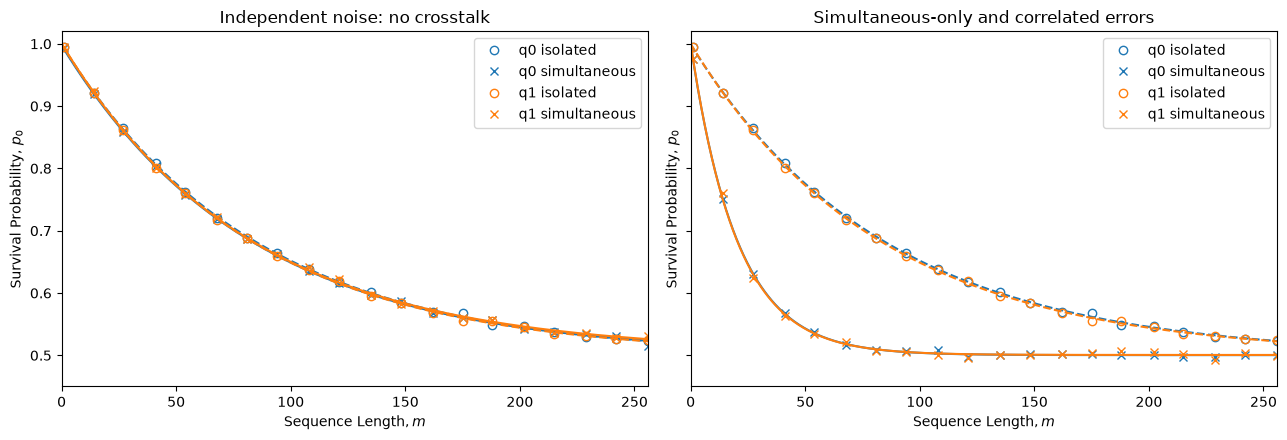

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
no_xtalk_benchmark.plot(axes[0])
xtalk_benchmark.plot(axes[1])
axes[0].set_title("Independent noise: no crosstalk")
axes[1].set_title("Simultaneous-only and correlated errors")
fig.tight_layout()

## Reading a hardware result

On hardware, replace the example device with the appropriate QCMet `BaseDevice`. Look for:

- **curve separation:** simultaneous survival decays faster than isolated survival;
- **positive addressability error:** simultaneous EPC minus isolated EPC exceeds its uncertainty;
- **nonzero correlation parameter:** joint parity decay does not factor into individual parity decays.

A higher simultaneous EPC alone shows reduced addressability. A nonzero correlation parameter  indicates the presence of dependent errors.